In [21]:
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.common.keys import Keys
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.support.ui import Select
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
import time

In [22]:
driver = webdriver.Chrome()
driver.get("https://vahan.parivahan.gov.in/vahan4dashboard/vahan/vahan/view/reportview.xhtml")

In [23]:
states = ["Andhra Pradesh","Assam", "Delhi", "Gujarat", "Haryana", "Jharkhand", "Karnataka", "Kerala", "Maharashtra", "Madhya Pradesh", 
          "Odisha", "Punjab", "Rajasthan", "Tamil Nadu", "Uttarakhand", "Uttar Pradesh", "West Bengal"]
v_data=[]
for state_name in states:
    driver.find_element(By.XPATH, "/html/body/form/div[2]/div/div/div[1]/div[2]/div[3]/div/div[3]/span").click() #dropdown
    time.sleep(2)
    driver.find_element(By.XPATH, f"//li[contains(text(),'{state_name}')]").click() #state
    time.sleep(2)
    driver.find_element(By.XPATH, "/html/body/form/div[2]/div/div/div[1]/div[3]/div[2]/div[2]/div[2]/div/div[3]/span").click() #dropdown
    time.sleep(2)
    driver.find_element(By.XPATH, "//li[contains(text(),'Till Today')]").click() #till today
    time.sleep(2)
    driver.find_element(By.XPATH, "/html/body/form/div[2]/div/div/div[1]/div[3]/div[3]/div/button/span[2]").click() #refresh
    time.sleep(2)
    driver.find_element(By.XPATH, "/html/body/form/div[2]/div/div/div[3]/div/div[2]/div/div/div[1]/div[1]/div/div[3]/span").click() # dropdown
    time.sleep(2)
    driver.find_element(By.XPATH, f"//li[contains(text(),'GOODS VEHICLES')]").click()
    time.sleep(2)
    rows = driver.find_elements(By.TAG_NAME, "tr")
    for row in rows:
        try:
            cols = row.find_elements(By.TAG_NAME, "td")
            cols_text = [col.text.strip() for col in cols]
            if len(cols_text) == 6:
                s_no = cols_text[0]
                vehicle_class = cols_text[1]
                lgv = cols_text[2]
                mgv = cols_text[3]
                hgv = cols_text[4]
                total = cols_text[5]
            v_data.append([state_name, s_no, vehicle_class, lgv, mgv, hgv, total])
        except:
            continue

In [28]:
import pandas as pd
import numpy as np

df = pd.DataFrame(v_data, columns=["State", "Sno", "Vehicle_Class", "LGV", "MGV", "HGV", "Total"])
df["LGV"] = df["LGV"].str.replace(",", "").astype(int)
df["MGV"] = df["MGV"].str.replace(",", "").astype(int)
df["HGV"] = df["HGV"].str.replace(",", "").astype(int)
df["Total"] = df["Total"].str.replace(",", "").astype(int)
df.tail()

,State,Sno,Vehicle_Class,LGV,MGV,HGV,Total
2462,West Bengal,4,MOBILE CLINIC,269,4,6,279
2463,West Bengal,1,ARTICULATED VEHICLE,50,10,14007,14067
2464,West Bengal,2,CASH VAN,1530,9,0,1539
2465,West Bengal,3,GOODS CARRIER,440558,42451,394875,877884
2466,West Bengal,4,MOBILE CLINIC,286,6,6,298


In [30]:
goods_carrier = df[df['Vehicle_Class'] == 'GOODS CARRIER']
goods_carrier = goods_carrier[['State', 'LGV', 'MGV', 'HGV', 'Total']]
goods_carrier

,State,LGV,MGV,HGV,Total
2,Andhra Pradesh,292777,30297,250816,573890
156,Assam,226057,6588,73062,305707
309,Delhi,335290,24108,53901,413299
463,Gujarat,597797,66539,431610,1095946
617,Haryana,307146,62618,400007,769771
771,Jharkhand,144770,14243,186388,345401
925,Karnataka,806048,98889,470285,1375222
1079,Kerala,447616,64523,100907,613046
1233,Maharashtra,1128159,109499,562613,1800271
1387,Madhya Pradesh,370662,23509,234020,628191


In [32]:
goods_carrier = goods_carrier.sort_values('Total',ascending = False)
top5 = goods_carrier.head()
top5.to_csv("goods_carrier_category.csv", index=False)

In [33]:
top5

,State,LGV,MGV,HGV,Total
1233,Maharashtra,1128159,109499,562613,1800271
2003,Tamil Nadu,913166,122507,379095,1414768
925,Karnataka,806048,98889,470285,1375222
2311,Uttar Pradesh,742757,53865,446198,1242820
463,Gujarat,597797,66539,431610,1095946


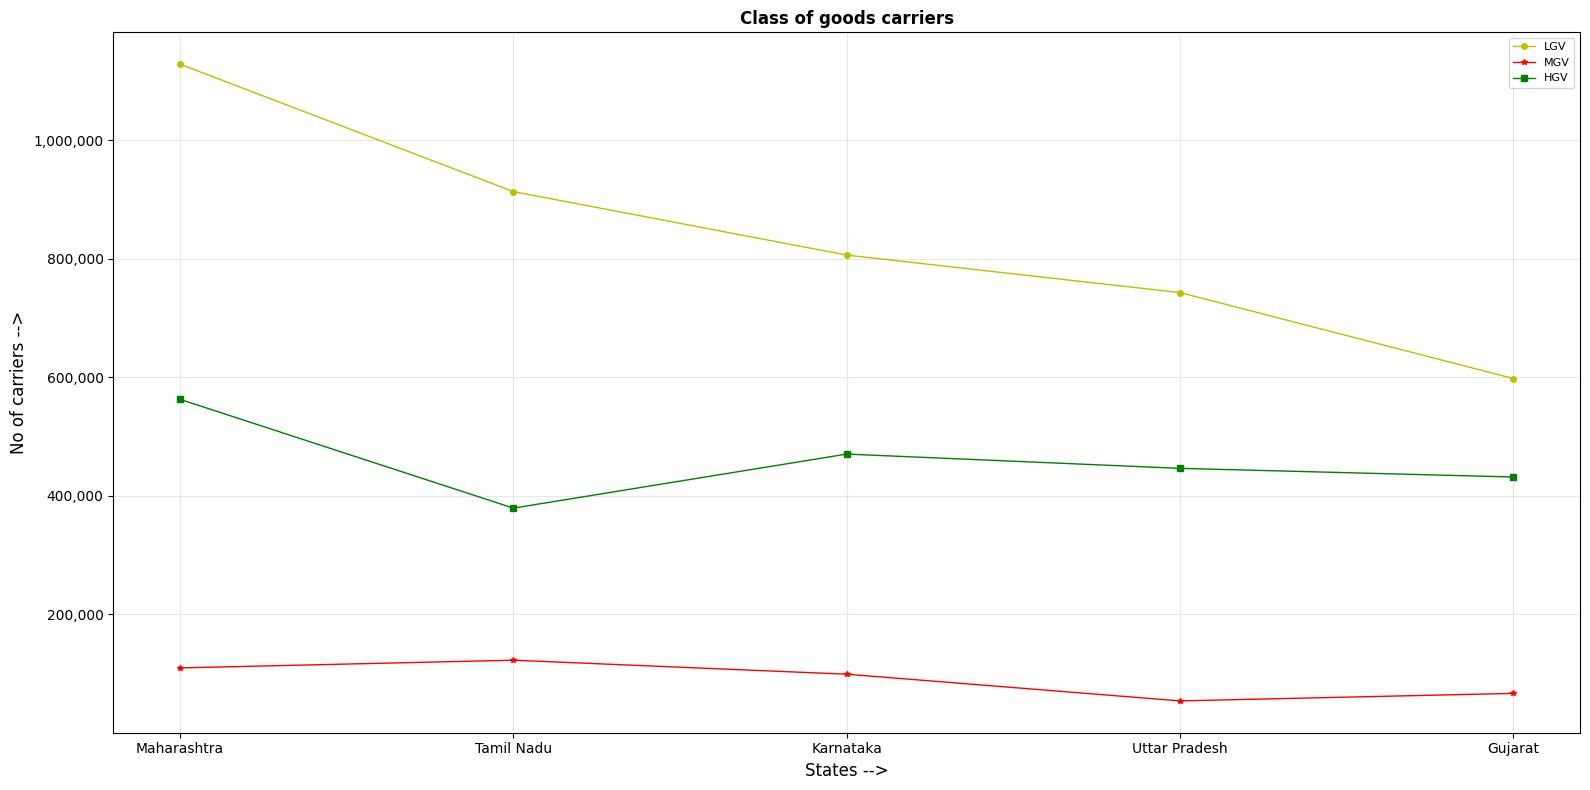

In [46]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(16,8))
ax.plot(top5['State'], top5['LGV'],'y-',marker='o',linewidth=1,markersize=4, label="LGV")
ax.plot(top5['State'], top5['MGV'],'r-',marker='*',linewidth=1,markersize=4, label="MGV")
ax.plot(top5['State'], top5['HGV'],'g-',marker='s',linewidth=1,markersize=4, label="HGV")
ax.set_title('Class of goods carriers',fontsize=12,fontweight='bold')
ax.set_xlabel('States -->', fontsize=12)
ax.set_ylabel('No of carriers -->',fontsize=12)
ax.ticklabel_format(style='plain', axis='y')
import matplotlib.ticker as mticker

ax = plt.gca()
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)
plt.savefig('class of goods carriers', dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()